<a href="https://colab.research.google.com/github/Vincent-L0/A02-eda-and-visualization/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Vincent lam

**Date:** 9/9/26

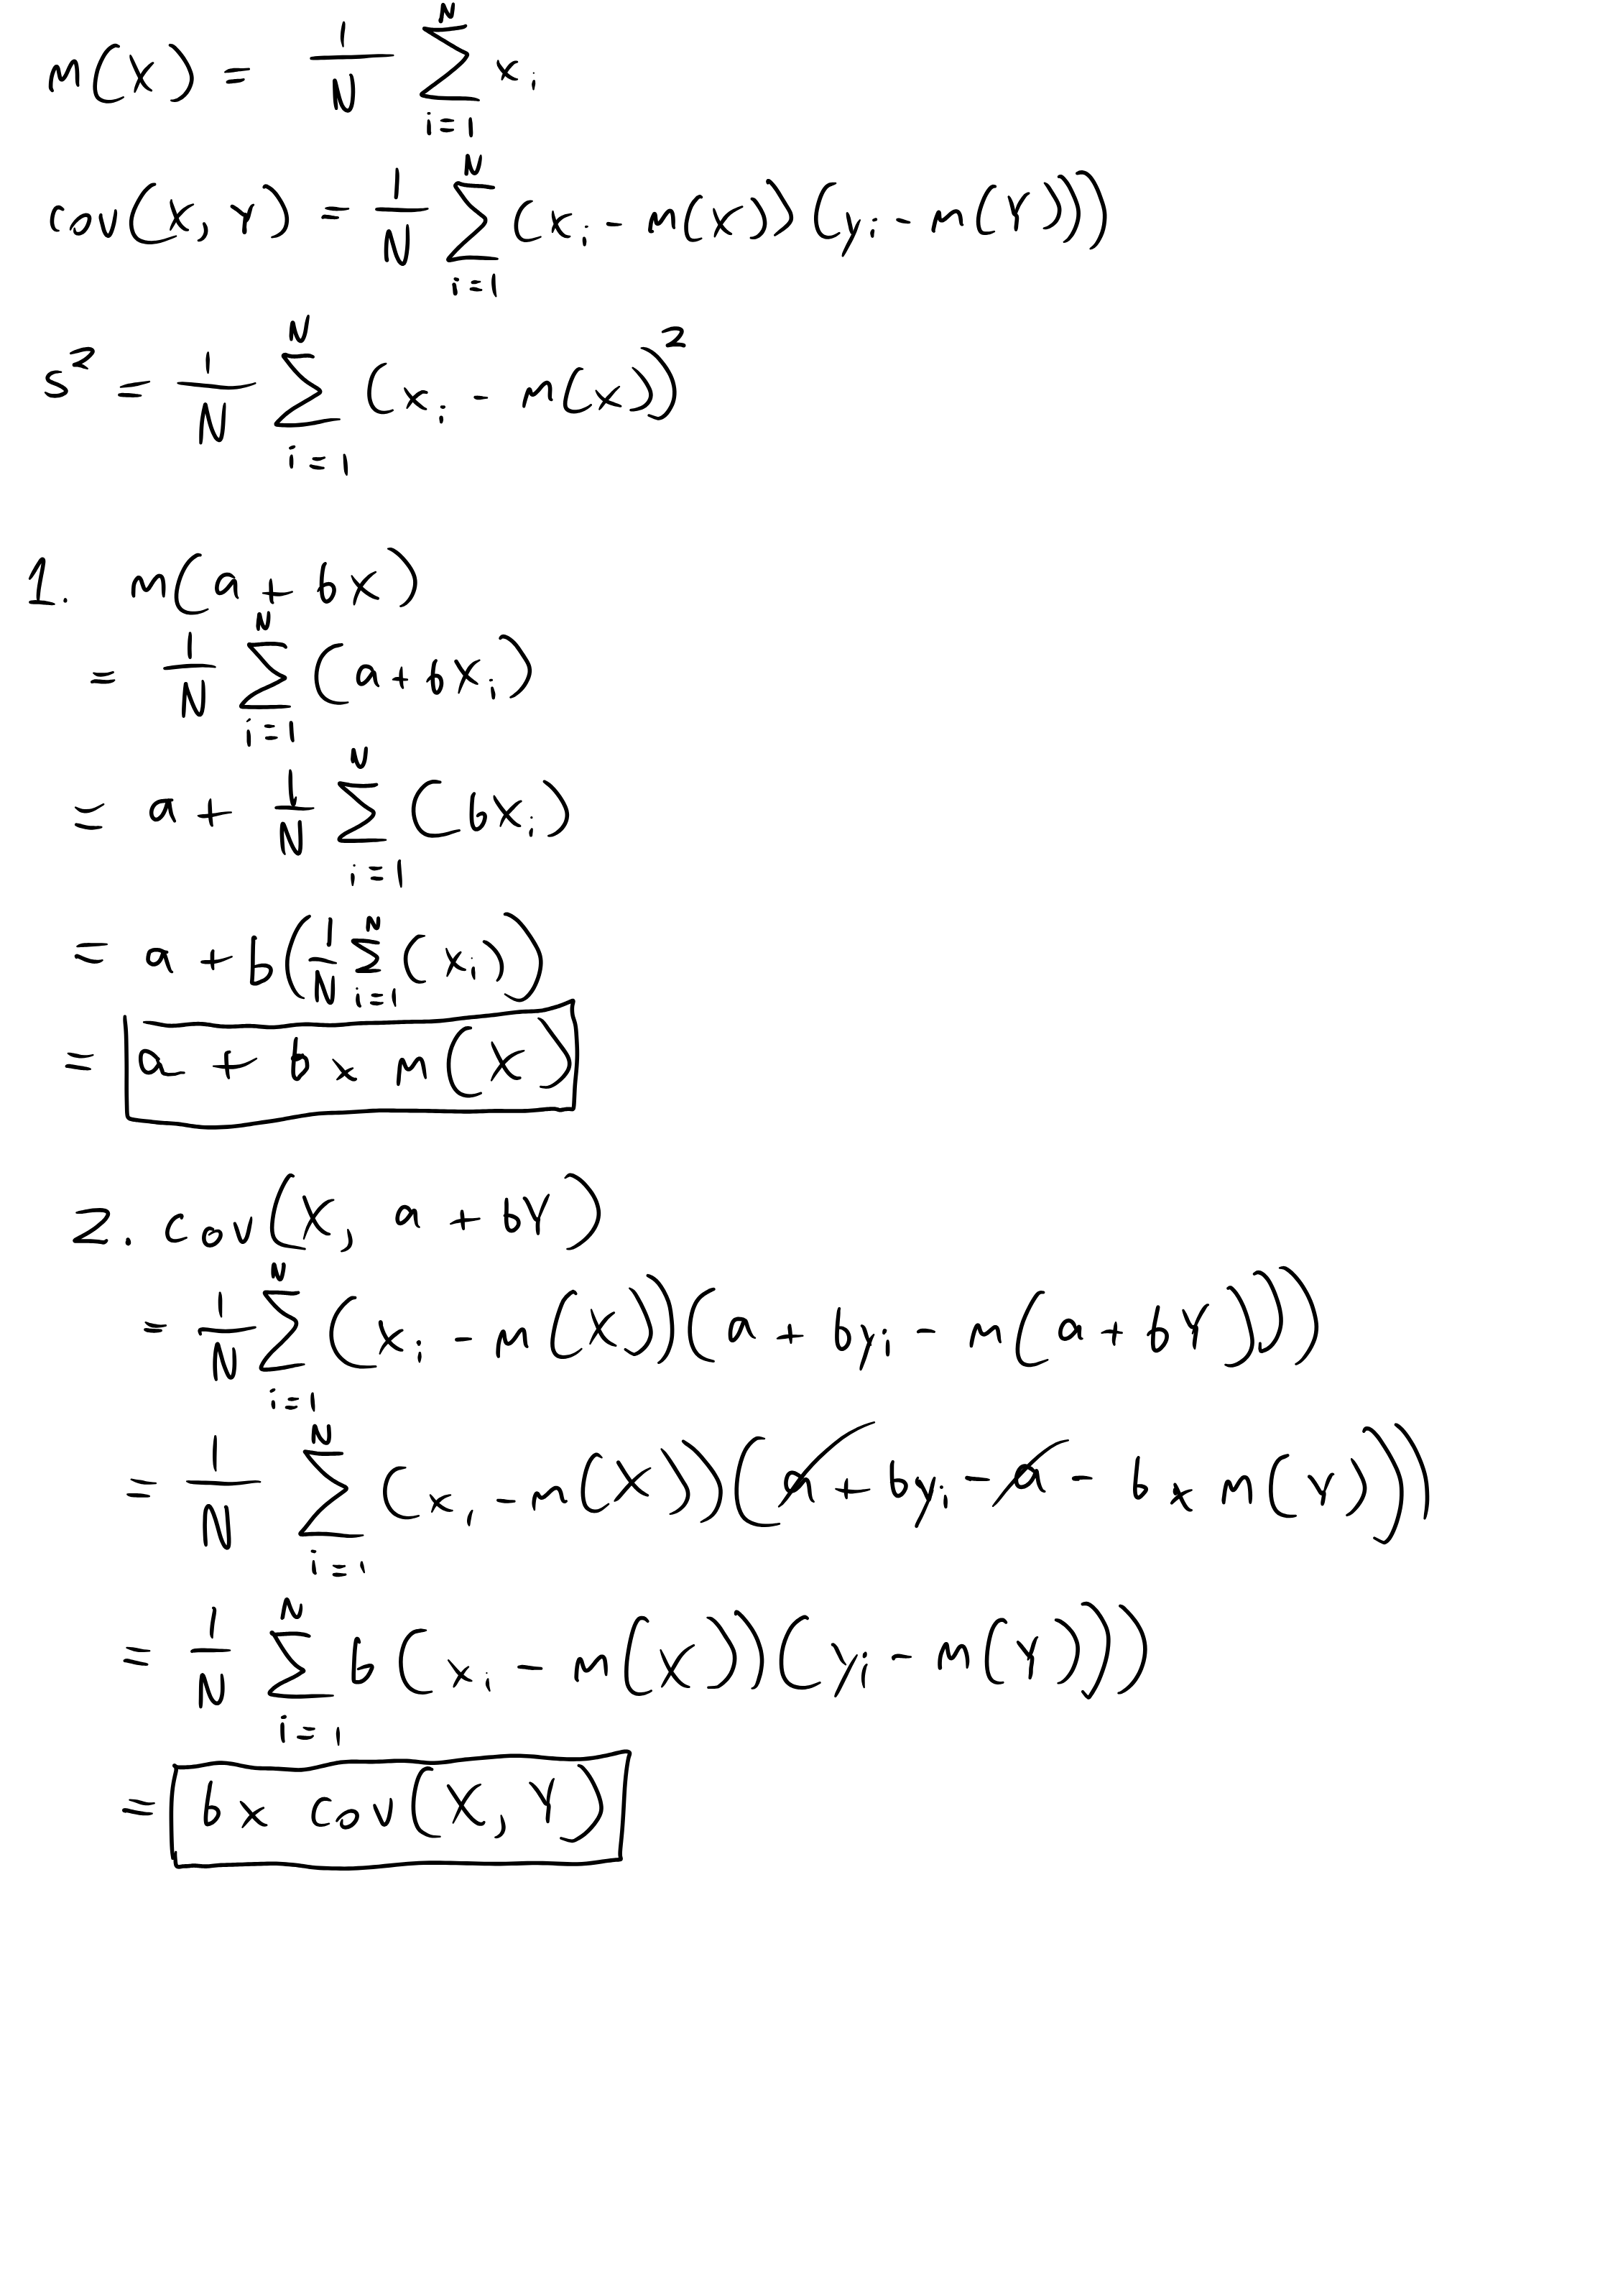

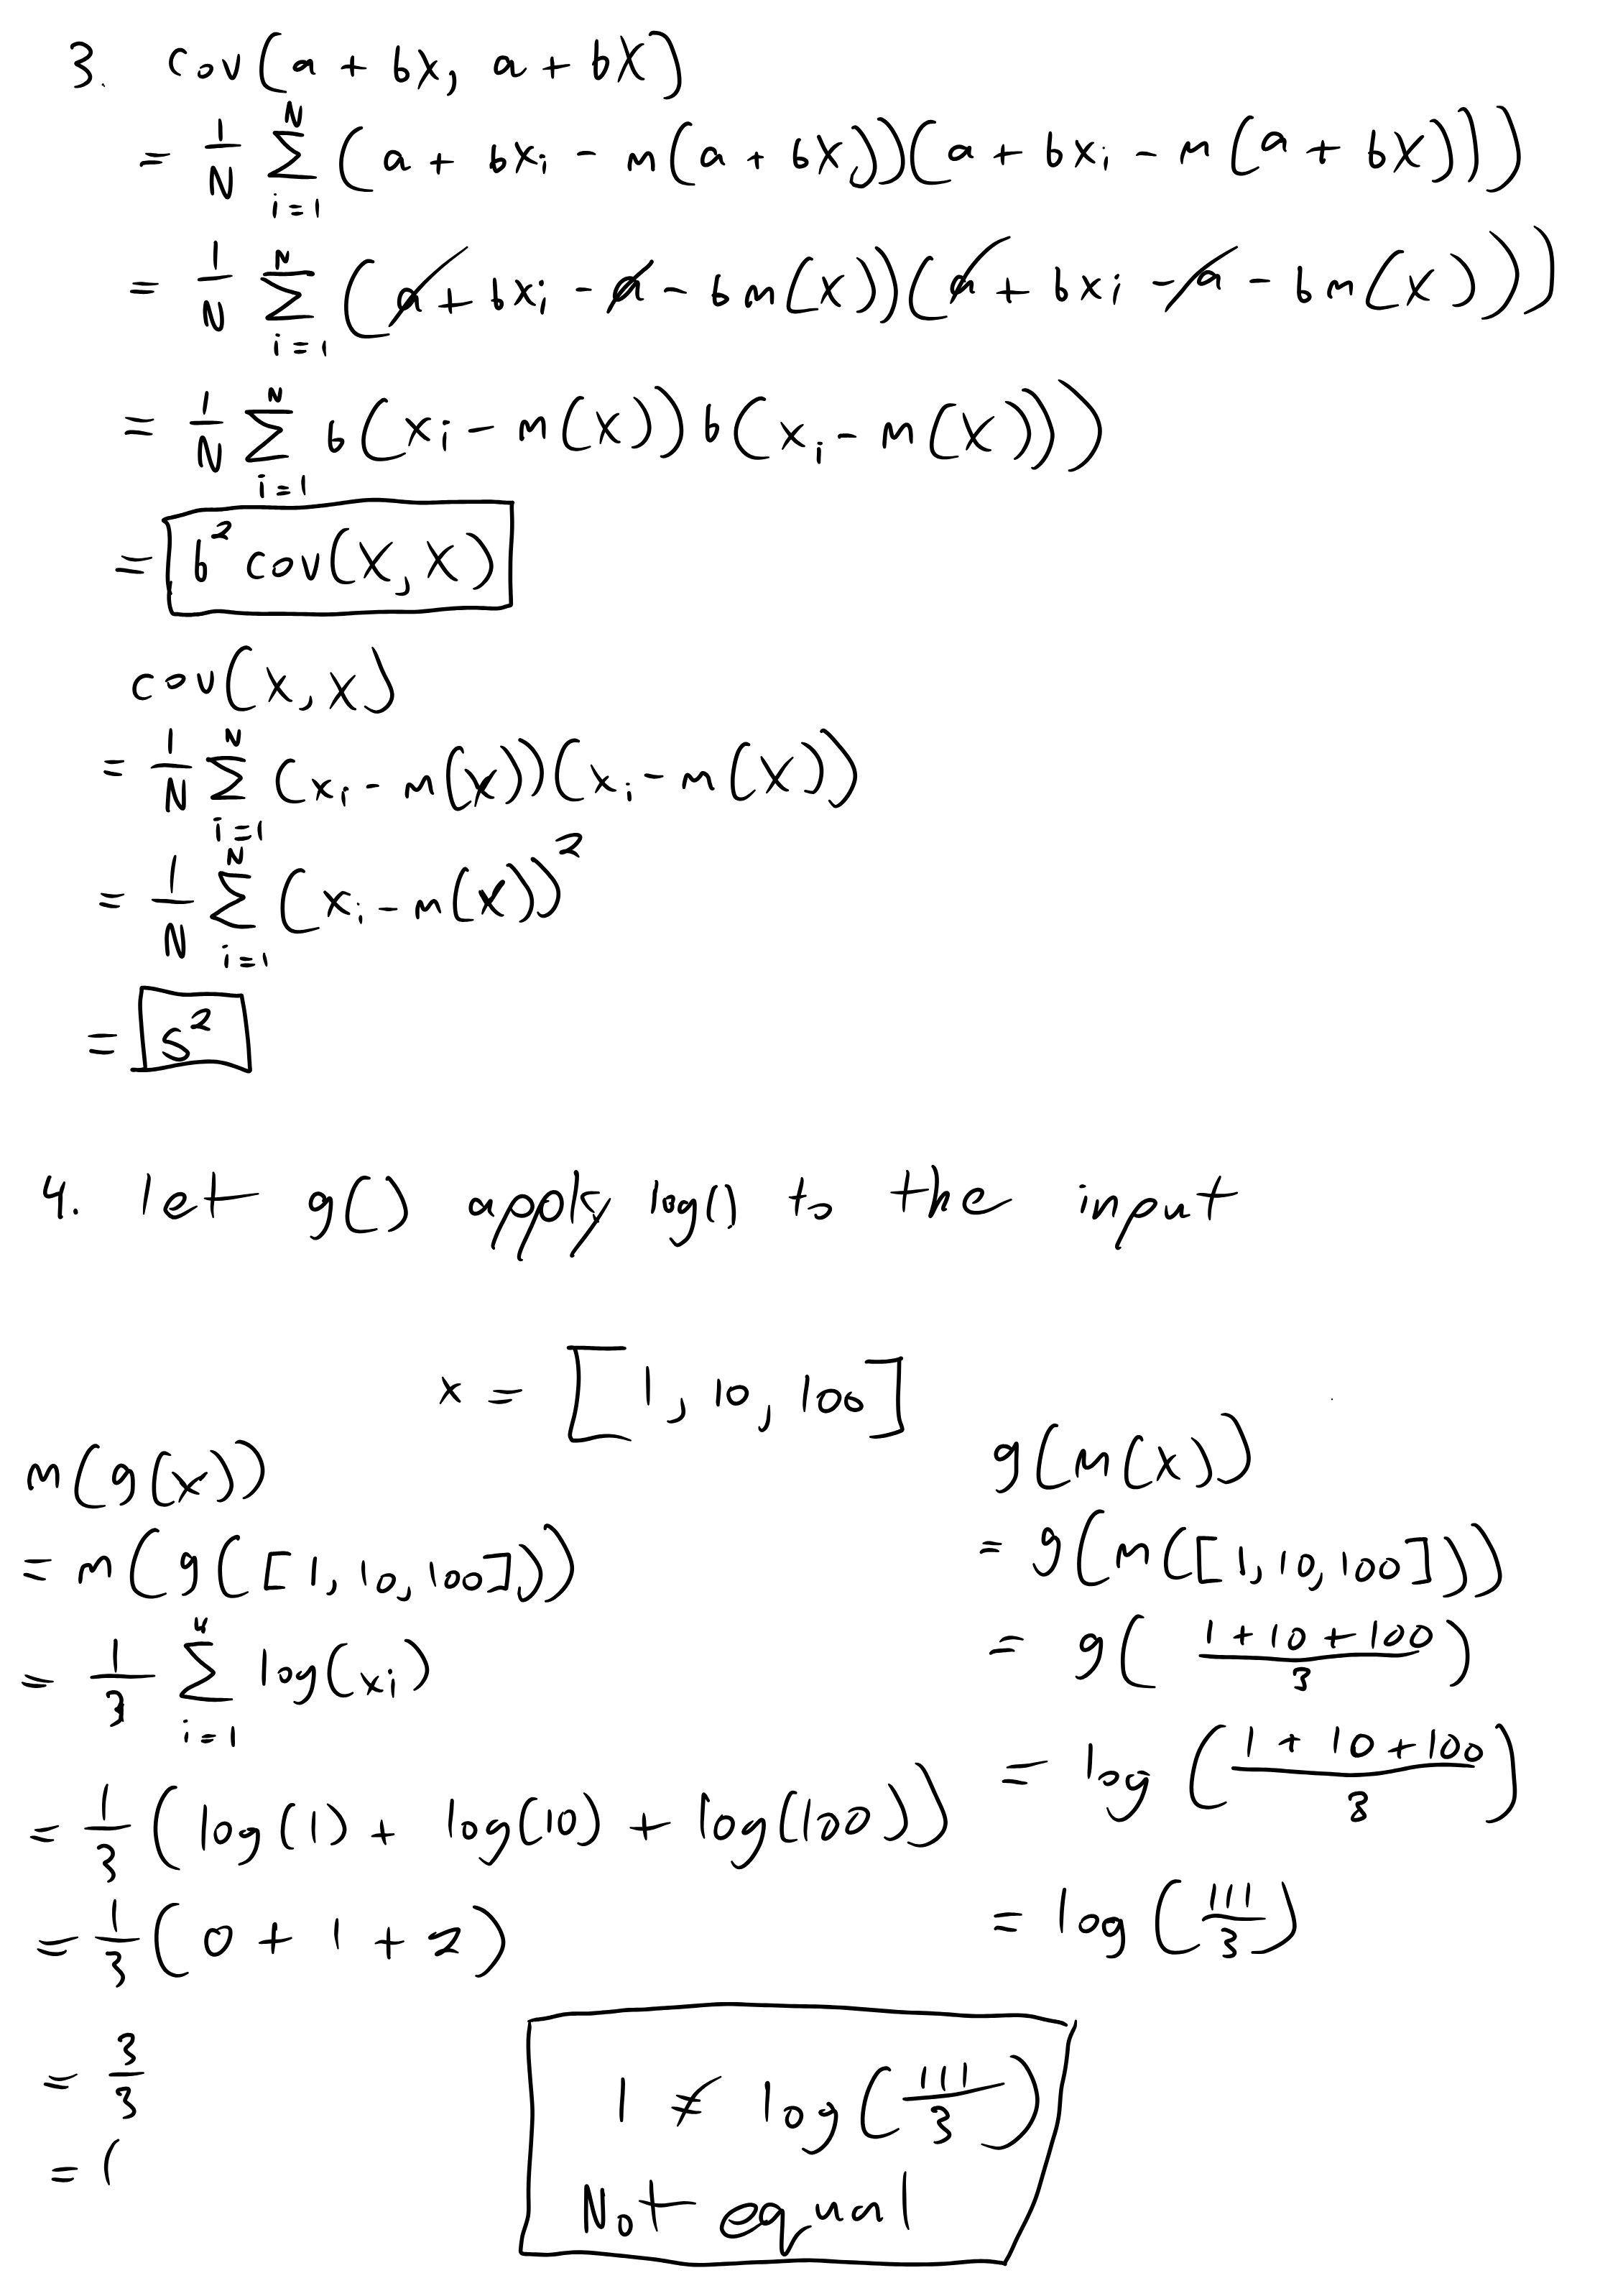

In [ ]:
# Your Phase 1 solution to the problem goes here.
from PIL import Image
from IPython.display import display

img1 = Image.open('/content/sample_data/Q1_1.png')
display(img1)
img2 = Image.open('/content/sample_data/Q1_2.png')
display(img2)

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
The value of Foreign Gift Amount ranges from $-537770 to $99999999. It is also right skewed.


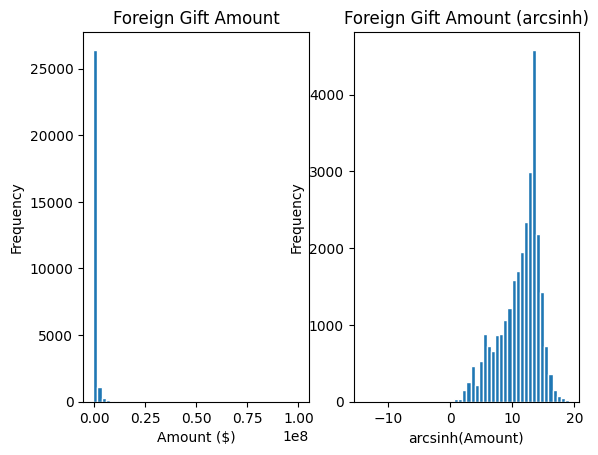

Gift Type Counts Table:
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
dtype: int64

Gift Type Proportions Table:
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
dtype: float64


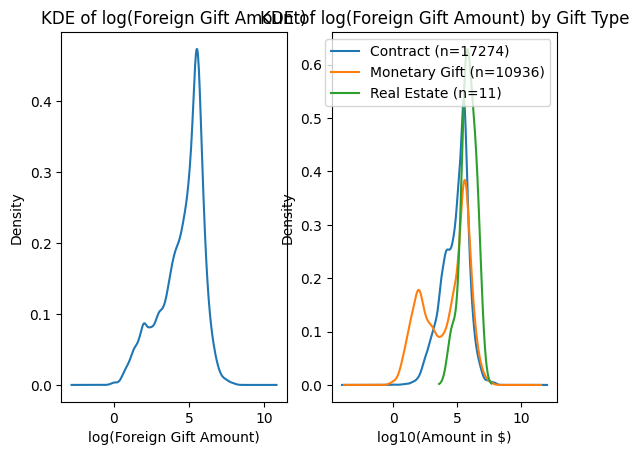

Top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 countries by total amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA              

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data into df
df = pd.read_csv('/content/ForeignGifts_edu.csv')

#2
# describe the 'Foreign Gift Amount' column and additional information
print(df['Foreign Gift Amount'].describe())
print('The value of Foreign Gift Amount ranges from $', df['Foreign Gift Amount'].min(), ' to $', df['Foreign Gift Amount'].max(), '. It is also right skewed.', sep = '')

# creates a plot to store graphs (1 column x 2 rows)
fig, axes = plt.subplots(1, 2)

# adds a histogram of 'Foreign Gift Amount' to the first plot
axes[0].hist(df['Foreign Gift Amount'], bins=50, edgecolor='white')
axes[0].set(title='Foreign Gift Amount', xlabel='Amount ($)', ylabel='Frequency')

# adds a histogram of 'Foreign Gift Amount' after applying the arcsinh function to the second plot
arcsinh_amount = np.arcsinh(df['Foreign Gift Amount'])
axes[1].hist(arcsinh_amount, bins=50, edgecolor='white')
axes[1].set(title='Foreign Gift Amount (arcsinh)', xlabel='arcsinh(Amount)', ylabel='Frequency')

plt.show()

#3
# assigns 'gift_type_counts' 4 groups, one for every type in 'Gift Type' and sorts it from highest to lowest frequency
gift_type_counts = df.groupby('Gift Type').size().sort_values(ascending=False)
# assigns 'gift_type_props' 4 groups representing the proportions of each unique 'Gift Type' for all gifts
gift_type_props = gift_type_counts / gift_type_counts.sum()

# prints the above variables
print('Gift Type Counts Table:')
print(gift_type_counts)
print('\nGift Type Proportions Table:')
print(gift_type_props)

#4
# creates a new column representing the log of the positive values from 'Foreign Gift Amount'
df['Foreign Gift Amount Log'] = np.log10(df['Foreign Gift Amount'].where(df['Foreign Gift Amount'] > 0))

# drops the negative (now na) values of 'Foreign Gift Amount Log'
x = df['Foreign Gift Amount Log'].dropna()

# assigns 'N' the number of (positive) values in 'Foreign Gift Amount Log'
N = len(x)

# defines the kernel function
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

kde = sum(normal_kernel(value, h_s) for value in x) / N

# creates a plot to store graphs (1 column x 2 rows)
fig, axes = plt.subplots(1, 2)

# plots the KD plot for log('Foreign Gift Amount')
axes[0].plot(grid, kde)
axes[0].set(title='KDE of log(Foreign Gift Amount)', xlabel='log(Foreign Gift Amount)', ylabel='Density')

# plots the KD plot for log('Foreign Gift Amount') for each type of gift
for gift_type, group in df.groupby('Gift Type'):
    if len(group) > 1:
        group['Foreign Gift Amount Log'].plot(kind='kde', ax=axes[1], label=f'{gift_type} (n={len(group)})')

axes[1].set(title='KDE of log(Foreign Gift Amount) by Gift Type', xlabel='log10(Amount in $)')
axes[1].legend()

plt.show()

#5
# assigns 'top15_country_count' several groups, one for every country in 'Country of Giftor' and sorts it from highest to lowest frequency
top15_country_count = df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)

# assigns 'top15_country_amount' the sum of all donations from every donor from all countries
top15_country_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

# prints the variables above
print('Top 15 countries by number of gifts:')
print(top15_country_count)
print('\nTop 15 countries by total amount given:')
print(top15_country_amount,"\n")

# assigns 'giftor_totals' the top 15 gifting organizations/individuals in terms of their total amount donated and prints it
giftor_totals = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(giftor_totals.head(15))


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]